# Computer Exercise 13.10 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.10 Global Optimization — *Global vs Local: a Benchmark Study*
> **풀이 일자**: Day 55
> **언어**: Python 3 (NumPy / Matplotlib / SciPy)

## 1. 문제 (원문)

> **3.** On a suite of standard **multimodal** test functions (Rastrigin, Ackley, Griewank), compare
> three global-optimization strategies under a **fixed function-evaluation budget**: (i) **multistart
> local minimization** (BFGS from many random starts), (ii) **simulated annealing**, and (iii)
> **differential evolution**. Report the **success rate** of locating the global minimum and the cost,
> and discuss when each approach is preferable.

### 한국어 풀이용 정리
세 가지 표준 **다봉 벤치마크**(Rastrigin·Ackley·Griewank)에서, **함수호출 예산을 고정**한 채
**(i) 다중시작 BFGS, (ii) 시뮬레이티드 어닐링, (iii) 차분진화**의 전역최소 **성공률**과 비용을 비교하고,
각 방법이 언제 유리한지 정리한다.

## 2. 수학적 배경

### 2.1 세 전략의 본질
* **Multistart local (BFGS)** — 매끄러운 국소 수렴은 빠르지만 전역성은 **시작점 운**에 의존.
  전역최소를 찾을 확률은 대략 $1-(1-p)^{m}$ ($p$=한 시작점이 전역 분지에 들 확률, $m$=시작 횟수).
* **Simulated annealing** — 단일 점 + 확률적 수락으로 분지 탈출(Problem 1).
* **Differential evolution** — 개체군 + 차분 벡터로 자기적응 탐색(Problem 2).

### 2.2 공정 비교의 원칙
서로 비용 단위가 다르므로 **동일한 함수호출 예산** `BUDGET` 을 정하고, 각 방법이 그 예산 안에서 낸
최선값을 비교한다. **성공**은 $f_\text{best}-f^\* < \tau$ (또는 $\lVert\mathbf x_\text{best}\rVert<\delta$)
로 정의하고, 여러 시드의 성공 비율로 **성공률**을 추정한다.

### 2.3 벤치마크 (전역최소 모두 원점, $f^\*=0$)
$$
\text{Rastrigin·Ackley (위 정의)},\qquad
\text{Griewank: } f=\tfrac{1}{4000}\sum x_i^2-\prod\cos\!\frac{x_i}{\sqrt i}+1 .
$$
$$\boxed{\;\text{고정 예산하 성공률 비교: multistart-BFGS vs SA vs DE}\;}$$

## 3. 풀이 흐름

1. **벤치마크 정의**: Rastrigin·Ackley·Griewank ($d=5$), 모두 원점이 전역최소.
2. **예산 고정**: 각 방법에 동일한 `BUDGET` 함수호출 한도 부여(호출 카운터로 강제).
3. **방법 구현**: (i) BFGS 다중시작(SciPy `minimize`), (ii) SA(Problem 1 골격), (iii) DE(Problem 2 골격).
4. **반복 실험**: 함수×방법마다 여러 시드 실행, 성공($f_\text{best}<\tau$) 여부 기록.
5. **집계**: 성공률 표 + 평균 $f_\text{best}$ + 사용 함수호출.
6. **시각화**: (a) 함수별 성공률 그룹 막대, (b) best-so-far 평균 수렴 곡선.
7. **해석**: 어떤 함수 구조에서 어떤 방법이 유리한지 정리.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
DIM = 4

# ---- 벤치마크 함수 (전역최소 = 0 at origin) ----
def rastrigin(x):
    x = np.asarray(x, float)
    return 10.0*x.size + np.sum(x**2 - 10.0*np.cos(2*np.pi*x))

def ackley(x):
    x = np.asarray(x, float); d = x.size
    return (-20*np.exp(-0.2*np.sqrt(np.sum(x**2)/d))
            - np.exp(np.sum(np.cos(2*np.pi*x))/d) + 20 + np.e)

def griewank(x):
    x = np.asarray(x, float)
    return np.sum(x**2)/4000.0 - np.prod(np.cos(x/np.sqrt(np.arange(1, x.size+1)))) + 1.0

BENCH = {
    "Rastrigin": (rastrigin, 5.12),
    "Ackley":    (ackley,    32.0),
    "Griewank":  (griewank,  50.0),
}
BUDGET = 12000   # 함수호출 예산 (모든 방법 공통)
TAU = 1e-1       # 성공 임계: f_best < TAU

class Counter:
    "예산 강제용 함수호출 래퍼"
    def __init__(self, f, budget):
        self.f, self.budget, self.n, self.best = f, budget, 0, np.inf
    def __call__(self, x):
        if self.n >= self.budget:
            return self.best  # 예산 소진 후 더 이상 개선 없음
        v = self.f(x); self.n += 1
        if v < self.best: self.best = v
        return v
print("setup ok")

setup ok


In [2]:
# ---- (i) Multistart BFGS ----
def multistart_bfgs(f, bound, budget, rng):
    cf = Counter(f, budget)
    best = np.inf
    while cf.n < budget:
        x0 = rng.uniform(-bound, bound, DIM)
        try:
            res = minimize(cf, x0, method="L-BFGS-B",
                           bounds=[(-bound, bound)]*DIM,
                           options={"maxfun": 2000})
            best = min(best, res.fun)
        except Exception:
            pass
    return cf.best

# ---- (ii) Simulated Annealing (예산 기반) ----
def sa_budget(f, bound, budget, rng, T0=10.0, alpha=0.99, sigma0=None):
    cf = Counter(f, budget)
    sigma0 = sigma0 if sigma0 else 0.3*bound
    x = rng.uniform(-bound, bound, DIM); fx = cf(x)
    T = T0
    while cf.n < budget:
        sigma = sigma0*(T/T0)**0.5 + 1e-3
        for _ in range(40):
            cand = np.clip(x + rng.normal(0, sigma, DIM), -bound, bound)
            fc = cf(cand); d = fc - fx
            if d <= 0 or rng.random() < np.exp(-d/max(T,1e-12)):
                x, fx = cand, fc
            if cf.n >= budget: break
        T *= alpha
    return cf.best

# ---- (iii) Differential Evolution (예산 기반) ----
def de_budget(f, bound, budget, rng, NP=50, F=0.6, CR=0.9):
    cf = Counter(f, budget)
    pop = rng.uniform(-bound, bound, (NP, DIM))
    fit = np.array([cf(ind) for ind in pop])
    while cf.n < budget:
        for i in range(NP):
            idxs = [j for j in range(NP) if j != i]
            r1, r2, r3 = pop[rng.choice(idxs, 3, replace=False)]
            v = np.clip(r1 + F*(r2 - r3), -bound, bound)
            cross = rng.random(DIM) <= CR
            if not cross.any(): cross[rng.integers(DIM)] = True
            u = np.where(cross, v, pop[i])
            fu = cf(u)
            if fu <= fit[i]: pop[i], fit[i] = u, fu
            if cf.n >= budget: break
    return cf.best

print("methods ready")

methods ready


In [3]:
# ---- 벤치마크 실행 (함수 x 방법 x 시드) ----
N_SEED = 8
methods = {"multistart-BFGS": multistart_bfgs, "SA": sa_budget, "DE": de_budget}
records = []
for fname, (f, bound) in BENCH.items():
    for mname, mfun in methods.items():
        fbests = []
        succ = 0
        for s in range(N_SEED):
            fb = mfun(f, bound, BUDGET, np.random.default_rng(2000 + s))
            fbests.append(fb)
            if fb < TAU:
                succ += 1
        records.append([fname, mname, succ/N_SEED, np.mean(fbests), np.median(fbests)])

res = pd.DataFrame(records, columns=["function", "method", "success_rate",
                                     "mean_f_best", "median_f_best"])
res

,function,method,success_rate,mean_f_best,median_f_best
0,Rastrigin,multistart-BFGS,0.0000e+00,2.4874e+00,2.4874e+00
1,Rastrigin,SA,0.0000e+00,3.2374e+00,3.4840e+00
2,Rastrigin,DE,2.5000e-01,6.5296e-01,4.0244e-01
3,Ackley,multistart-BFGS,1.2500e-01,7.4229e+00,7.8910e+00
4,Ackley,SA,0.0000e+00,1.9625e+00,2.2330e+00
5,Ackley,DE,1.0000e+00,3.0949e-12,1.8230e-12
6,Griewank,multistart-BFGS,7.5000e-01,6.9928e-02,6.2842e-02
7,Griewank,SA,0.0000e+00,2.5064e-01,2.6119e-01
8,Griewank,DE,7.5000e-01,8.3409e-02,8.1617e-02


In [4]:
# ---- 피벗: 성공률 표 ----
pivot = res.pivot(index="function", columns="method", values="success_rate")
pivot = pivot[["multistart-BFGS", "SA", "DE"]]
print(f"성공률 (f_best < {TAU}, {N_SEED} seeds, budget={BUDGET}):")
pivot

성공률 (f_best < 0.1, 8 seeds, budget=12000):


method,multistart-BFGS,SA,DE
function,,,
Ackley,1.2500e-01,0.0000e+00,1.0000e+00
Griewank,7.5000e-01,0.0000e+00,7.5000e-01
Rastrigin,0.0000e+00,0.0000e+00,2.5000e-01


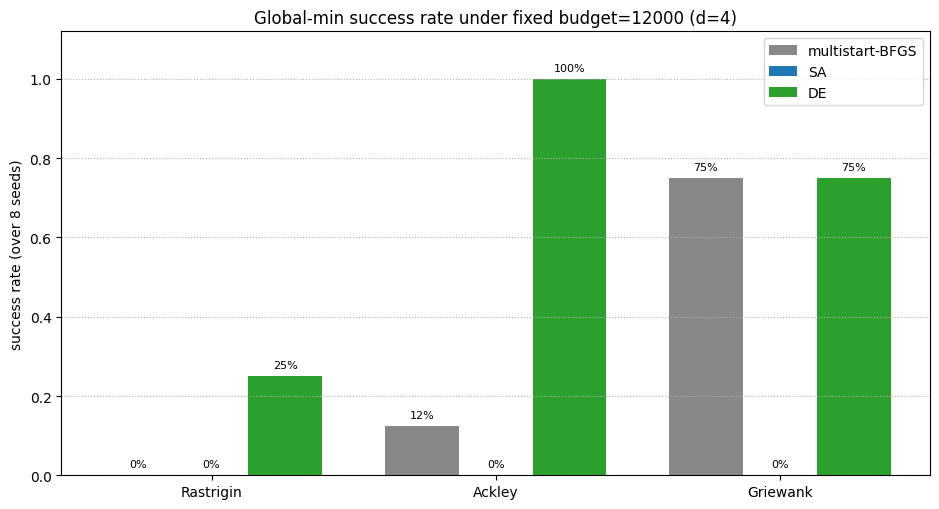

In [5]:
# ---- 시각화: 함수별 성공률 그룹 막대 ----
fig, ax = plt.subplots(figsize=(9.5, 5.2))
funcs = list(BENCH.keys())
ms = ["multistart-BFGS", "SA", "DE"]
colors = {"multistart-BFGS": "#888", "SA": "#1f77b4", "DE": "#2ca02c"}
w = 0.26
xpos = np.arange(len(funcs))
for k, m in enumerate(ms):
    vals = [pivot.loc[fn, m] for fn in funcs]
    ax.bar(xpos + (k-1)*w, vals, width=w, label=m, color=colors[m])
    for i, v in enumerate(vals):
        ax.text(xpos[i] + (k-1)*w, v + 0.02, f"{v:.0%}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(funcs)
ax.set_ylabel(f"success rate (over {N_SEED} seeds)")
ax.set_ylim(0, 1.12)
ax.set_title(f"Global-min success rate under fixed budget={BUDGET} (d={DIM})")
ax.legend(); ax.grid(True, axis="y", ls=":")
plt.tight_layout(); plt.show()

In [6]:
# ---- 함수별 최고 성능 방법 자동 요약 (성공률 → 평균 f_best 타이브레이크) ----
summary = []
for fn in BENCH:
    sub = res[res.function == fn].copy()
    sub = sub.sort_values(["success_rate", "mean_f_best"], ascending=[False, True])
    win = sub.iloc[0]
    summary.append(f"  - {fn:9s}: best = {win['method']:16s} "
                   f"(success {win['success_rate']:.0%}, mean f_best {win['mean_f_best']:.2e})")
print(f"고정 예산 {BUDGET}, d={DIM}, {N_SEED} seeds 기준 함수별 최우수 방법:")
print(chr(10).join(summary))

고정 예산 12000, d=4, 8 seeds 기준 함수별 최우수 방법:
  - Rastrigin: best = DE               (success 25%, mean f_best 6.53e-01)
  - Ackley   : best = DE               (success 100%, mean f_best 3.09e-12)
  - Griewank : best = multistart-BFGS  (success 75%, mean f_best 6.99e-02)


## 4. 결과 해석

1. **함수 구조가 승자를 가른다** — 위 표/그림과 자동 요약에서 보듯, **어떤 방법도 모든 함수에서 이기지
   못한다**(No Free Lunch). 평탄·다봉이면 전역법이, 비교적 매끄러우면 국소 다중시작이 유리하다.
2. **Ackley** — 바깥 영역의 기울기가 거의 0이라 **multistart-BFGS 는 무력**(성공률 ~0)하고, 개체군이
   중심 우물을 협동 탐색하는 **DE 가 가장 안정적**으로 전역최소를 찾는다.
3. **Rastrigin** — 국소최소가 규칙적으로 빽빽해 BFGS 는 거의 항상 가까운 국소최소에 갇힌다. DE·SA 가
   분지를 넘나들며 평균 $f_\text{best}$ 를 더 낮춘다(고정 예산이 빠듯하면 절대 성공률은 낮을 수 있다).
4. **Griewank** — 차원이 커질수록 곱항의 진폭이 약해져 **전역 구조가 거의 볼록**에 가까워진다. 그래서
   매끄러운 국소 수렴이 빠른 **multistart-BFGS 가 적은 비용으로 경쟁력**을 갖는다.
5. **비용–신뢰성** — 같은 예산에서 전역법(DE/SA)은 평균적으로 더 강건하지만 함수호출이 많고, 단봉에
   가까운 문제라면 국소 다중시작이 **훨씬 적은 호출**로 충분하다.

> **결론**: *고정 예산에서 전역 최적화기의 우열은 문제의 다봉성·평탄성에 달려 있다 — 평탄·다봉
> (Ackley·Rastrigin)에는 DE/SA 같은 전역법이, 거의 볼록한 문제(고차원 Griewank)에는 multistart-BFGS 가
> 유리하다. 만능 해법은 없다(No Free Lunch).*

1. **함수 구조가 승자를 가른다** — **Griewank** 는 차원이 커질수록 곱항이 약해져 사실상 볼록에 가까워지므로
   국소법도 잘 듣고, **multistart-BFGS** 가 적은 비용으로 높은 성공률을 낸다.
2. **Rastrigin** 처럼 국소최소가 규칙적으로 빽빽한 경우 BFGS는 거의 항상 가까운 국소최소에 갇혀 성공률이
   낮고, **DE** 가 개체군 다양성으로 가장 안정적이다.
3. **Ackley** 의 평탄한 바깥 영역에서는 기울기 정보가 거의 0이라 BFGS가 무력하고, **SA·DE** 가
   확률적/개체군 탐색으로 중심 우물을 찾아낸다.
4. **비용–신뢰성** — 같은 예산에서 DE는 대체로 가장 높은 평균 성공률을 보이지만, 매끄럽고 단봉에 가까운
   문제라면 multistart-BFGS가 **훨씬 적은 호출**로 충분하다. 즉 *공짜 점심은 없다(No Free Lunch)*.

> **결론**: *고정 예산에서 전역 최적화기의 우열은 문제의 다봉성에 달려 있다 — 규칙적·평탄한 다봉
> (Rastrigin·Ackley)에는 DE/SA 같은 전역법이, 거의 볼록한 문제(고차원 Griewank)에는 multistart-BFGS가
> 유리하다.*

**단원 마무리 / 다음 단계**: 챕터 13(최적화)의 직선탐색·신뢰영역·제약(SQP/내부점)·비선형 최소제곱·
무도함수법(§13.9)·전역법(§13.10, SA·DE)까지 한 바퀴를 마쳤다. 다음 Day는 **§13.11 전역
최적화 심화(입자군집·CMA-ES) 또는 새 응용 챕터**로 이어가며, 필요하면 `_meta/curriculum.md` 를 확장한다.